In [8]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [9]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (98, 46)
B = (98, 54)
# M = (48, 98)
# N = (51, 98)

M = (98, 48)
N = (98, 52)


### On met une matrice de conductivité

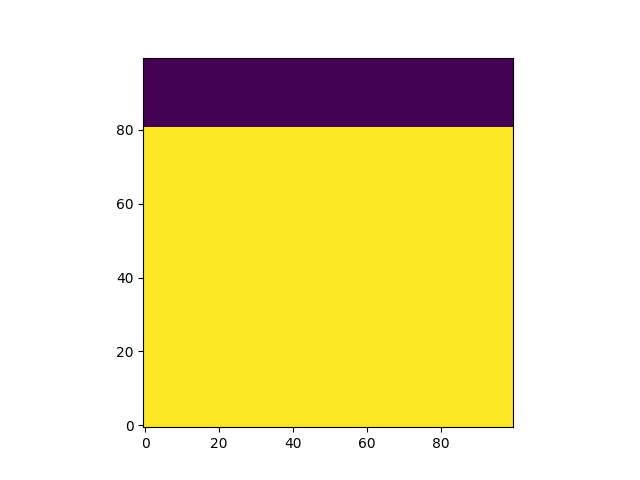

In [10]:
sigma_init = np.ones((dim, dim))#np.random.uniform(low=1, high=10, size=(dim, dim))
sigma_init[: 81, dim//2 - 50: dim//2 + 50] = 10
pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0]:dim, A[1]] = I
courant_init[B[0]:dim, B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')

# plt.imshow(courant_init, origin='lower')



### Calcul du potentiel

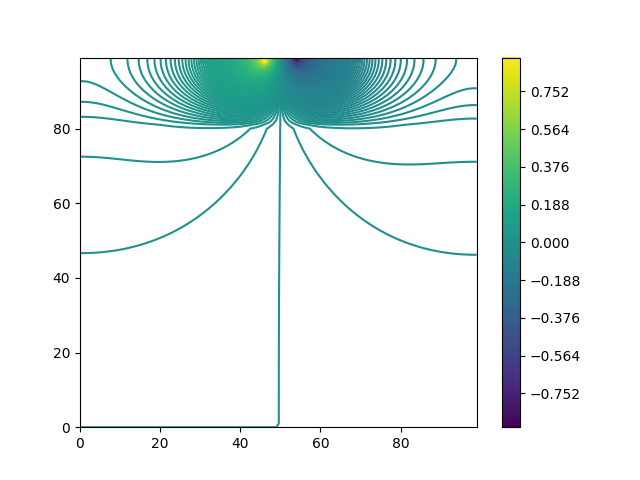

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import numba

%matplotlib widget



niter = 1000000
tol = 1e-8
error=1e10
it=0

@numba.jit
def compute_pot(V, V_k, Sigma, I):
    l = len(V[0])
    h = 1
    for i in range(1, l-1):
        for j in range(1, l-1):
            
            sigma_ifhs = (2*Sigma[j, i]*Sigma[j, i+1])/(Sigma[j, i] + Sigma[j, i+1])
            sigma_ibhs = (2*Sigma[j, i]*Sigma[j, i-1])/(Sigma[j, i] + Sigma[j, i-1])
            sigma_jfhs = (2*Sigma[j, i]*Sigma[j+1, i])/(Sigma[j, i] + Sigma[j+1, i])
            sigma_jbhs = (2*Sigma[j, i]*Sigma[j-1, i])/(Sigma[j, i] + Sigma[j-1, i])

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            nom = (I[j, i]*(h**2)) + sigma_ifhs*V_k[j, i+1] + sigma_ibhs*V_k[j, i-1] + sigma_jfhs*V_k[j+1, i] + sigma_jbhs*V_k[j-1, i]

            V[j, i] = nom/deno

    return V

@numba.jit
def find_pot(V, Sigma, I, DIM, error=1e10, tol=1e-8, niter=1000000):
    it=0
    while error > tol and it < niter:
        V_k = V.copy()

        V[0, :] = 0 # haut
        V[-1, :] = V[-2, :] # bas
        V[:, 0] = V[:, 1] # gauche
        V[:, DIM-1] = V[:, DIM-2] # gauche
        #  = 0 # droite

        V = compute_pot(V, V_k, Sigma, I)

        diff = V - V_k
        error = np.sqrt(np.sum(diff**2))#np.linalg.norm(diff)

        it += 1

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=500)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [12]:
def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

def pot_for_schlumb(V, M, N):
    dV = V[M] - V[N]
    return dV


def app_res(coord_ab, dimension, cond, I):
    V_i = np.zeros((dimension, dimension))

    rho_app = []
    AB_2 = []

    for i in coord_ab:
        a, b = i
        AB_2.append(abs(b-a)/2)
        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        I0[98:, a]=I
        I0[98:, b]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = pot_for_schlumb(V, M, N)

        # print(M, N)
        # print(a, b)

        K = np.pi * (((abs(b-a)/2)**2 - (abs(M[1]-N[1])/2)**2) / abs(M[1]-N[1]))#(2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

        rho_ap = K*V_MN/I
        rho_app.append(rho_ap)

    return np.array(rho_app), np.array(AB_2)

rho_a, ab2 = app_res(c, dim, sigma_init, I)






### Résistivité apparente du sol

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

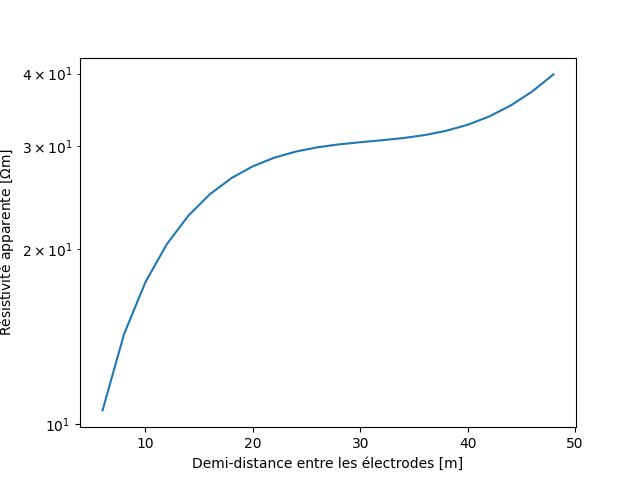

In [13]:


plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

# plt.show()

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol.

In [ ]:

def position_centre_electrode(dim):
    pass

def pseudo_section(dimension, cond, I):
    pseudo = np.zeros((dimension, dimension))

    A_i = (dimension-2, 0)
    M_i = (dimension-2, 2)
    N_i = (dimension-2, 4)
    B_i = (dimension-2, 6)

    ligne = dimension
    while B_i - A_i <= 100:
        print(B_i - A_i)
        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        
        I0[A_i[0]:, A_i[1]]=I
        I0[B_i[0]:, B_i[1]]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = pot_for_schlumb(V, M, N)

        a, b, m, n = A_i[1], B_i[1], M_i[1], N_i[1]

        K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))

        rho_ap = K*V_MN/I

        centre = 0.5(M[1] + N[1])

        pseudo[ligne, centre] = rho_ap
        ligne-=1
        A_i[1] += 1
        


    centre = 0.5(M_i[1] + N_i[1])



    pass


<>:32: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
C:\Users\obour\AppData\Local\Temp\ipykernel_40332\2102236445.py:32: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  centre = 0.5(M_i[1] + N_i[1])
